# Разработка модели для кластеризации базы клиентов

Имеется 2 файла - `mcdonalds.csv` с характеристиками клиентов ресторана быстрого питания и `exemplar.csv` с `id` эталонных клиентов, репрезентующих свой кластер.

Необходимо построить 4 разных кластера клиентов при помощи одного из известных алгоритмов кластеризации и в рамках каждого кластера присвоить всем клиентам метку наиболее репрезентативного клиента из `exemplar.csv`.

При помощи этой модели ресторан сможет определить маркетинговую стратегию для каждого клиента на основе выявленных архитипов из `exemplar.csv`.

Ваш файл должен иметь размерность `1453` строк на `2` столбца с полями `"id"` и `"Segment"`.

Минимальное значение метрики `Accuracy: 0.8`

In [45]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
# from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler, MinMaxScaler, MaxAbsScaler, LabelEncoder, OrdinalEncoder
# from sklearn.metrics.pairwise import euclidean_distances
import matplotlib.pyplot as plt
# import plotly.graph_objects as go

## 1. Анализ датасетов

In [46]:
mcdonalds = pd.read_csv('mcdonalds.csv')
exemplar = pd.read_csv('exemplar.csv')

In [47]:
mcdonalds.head()

,yummy,convenient,spicy,fattening,greasy,fast,cheap,tasty,expensive,healthy,disgusting,Like,Age,VisitFrequency,Gender,id
0,No,Yes,No,Yes,No,Yes,Yes,No,Yes,No,No,-3,61,Every three months,Female,0
1,Yes,Yes,No,Yes,Yes,Yes,Yes,Yes,Yes,No,No,+2,51,Every three months,Female,1
2,No,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,Yes,No,+1,62,Every three months,Female,2
3,Yes,Yes,No,Yes,Yes,Yes,Yes,Yes,No,No,Yes,+4,69,Once a week,Female,3
4,No,Yes,No,Yes,Yes,Yes,Yes,No,No,Yes,No,+2,49,Once a month,Male,4


In [48]:
mcdonalds.info()

<class 'pandas.DataFrame'>
RangeIndex: 1453 entries, 0 to 1452
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   yummy           1453 non-null   str  
 1   convenient      1453 non-null   str  
 2   spicy           1453 non-null   str  
 3   fattening       1453 non-null   str  
 4   greasy          1453 non-null   str  
 5   fast            1453 non-null   str  
 6   cheap           1453 non-null   str  
 7   tasty           1453 non-null   str  
 8   expensive       1453 non-null   str  
 9   healthy         1453 non-null   str  
 10  disgusting      1453 non-null   str  
 11  Like            1453 non-null   str  
 12  Age             1453 non-null   int64
 13  VisitFrequency  1453 non-null   str  
 14  Gender          1453 non-null   str  
 15  id              1453 non-null   int64
dtypes: int64(2), str(14)
memory usage: 181.8 KB


Поле `Like` сделано в виде строки. Сделаем маппинг в целые числа

In [49]:
mcdonalds.Like.unique()

<StringArray>
[          '-3',           '+2',           '+1',           '+4',
 'I love it!+5', 'I hate it!-5',           '-2',           '+3',
            '0',           '-4',           '-1']
Length: 11, dtype: str

In [50]:
like_dict = {
    '-3': -3,
    '+2': 2,
    '+1': 1,
    '+4': 4,
    'I love it!+5': 5,
    'I hate it!-5': -5,
    '-2': -2,
    '+3': 3,
    '0': 0,
    '-4': -4,
    '-1': -1
    }

mcdonalds['Like'] = mcdonalds['Like'].map(like_dict)

Преобразуем все поля, содержащие `Yes`/`No` в `1`/`0`

In [51]:
cols = ['yummy', 'convenient', 'spicy', 'fattening', 'greasy', 'fast', 'cheap', 'tasty', 'expensive', 'healthy', 'disgusting']
yes_no = {'Yes': 1, 'No': 0}
for c in cols:
    mcdonalds[c] = mcdonalds[c].map(yes_no)

Закодируем поле `VisitFrequency` с помощью OrdinalEncoder

In [52]:
mcdonalds.VisitFrequency.unique()

<StringArray>
[   'Every three months',           'Once a week',          'Once a month',
           'Once a year', 'More than once a week',                 'Never']
Length: 6, dtype: str

In [53]:
freq_map = {
    'Never': 5,
    'Once a year': 4,
    'Every three months': 3,
    'Once a month': 2,
    'Once a week': 1,
    'More than once a week': 0
}

mcdonalds['VisitFrequency'] = mcdonalds['VisitFrequency'].map(freq_map)

In [54]:
# freq_order = [['Never', 'Once a year', 'Every three months', 
#                'Once a month', 'Once a week', 'More than once a week']]

# ord_enc = OrdinalEncoder(categories=freq_order)
# mcdonalds['VisitFrequency'] = ord_enc.fit_transform(mcdonalds[['VisitFrequency']]).astype(int)

В общем-то поле `Gender` можно тоже закодировать 0/1. Но записей немного, поэтому лучше воспользуюсь One-Hot кодированием

In [55]:
gender_map = {
    'Female': 0,
    'Male': 1
}
mcdonalds['Gender'] = mcdonalds['Gender'].map(gender_map)

# mcdonalds = pd.get_dummies(mcdonalds, columns=['Gender'], prefix='Gender', dtype=int)


In [56]:
# # Положительные атрибуты (то, что обычно привлекает клиентов)
# positive = ['yummy', 'convenient', 'spicy', 'fast', 'cheap', 'healthy', 'tasty']
# mcdonalds['positive_count'] = mcdonalds[positive].sum(axis=1) / len(cols)

# # Отрицательные атрибуты (нездоровое/неприятное)
# negative = ['fattening', 'greasy', 'expensive',  'disgusting']

# mcdonalds['negative_count'] = mcdonalds[negative].sum(axis=1) / len(cols)

# # Общий индекс удовлетворенности (положительные минус отрицательные)
# mcdonalds['net_score'] = mcdonalds['positive_count'] - mcdonalds['negative_count']

Скалируем поля

In [57]:
mm_scaler = MinMaxScaler()
st_scaler = StandardScaler()
ma_scaler = MaxAbsScaler()
mcdonalds['Like'] = st_scaler.fit_transform(mcdonalds[['Like']])
mcdonalds['Age'] = st_scaler.fit_transform(mcdonalds[['Age']])
#mcdonalds['Gender'] = st_scaler.fit_transform(mcdonalds[['Gender']])
mcdonalds['VisitFrequency'] = st_scaler.fit_transform(mcdonalds[['VisitFrequency']])


# mcdonalds['positive_count'] = mm_scaler.fit_transform(mcdonalds[['positive_count']])
# mcdonalds['negative_count'] = -mm_scaler.fit_transform(mcdonalds[['negative_count']])
# mcdonalds['net_score'] = ma_scaler.fit_transform(mcdonalds[['net_score']])

In [58]:
mcdonalds.head()

,yummy,convenient,spicy,fattening,greasy,fast,cheap,tasty,expensive,healthy,disgusting,Like,Age,VisitFrequency,Gender,id
0,0,1,0,1,0,1,1,0,1,0,0,-1.212225,1.153258,0.296582,0,0
1,1,1,0,1,1,1,1,1,1,0,0,0.392515,0.449839,0.296582,0,1
2,0,1,1,1,1,1,0,1,1,1,0,0.071567,1.223600,0.296582,0,2
3,1,1,0,1,1,1,1,1,0,0,1,1.034411,1.715993,-1.250756,0,3
4,0,1,0,1,1,1,1,0,0,1,0,0.392515,0.309156,-0.477087,1,4


Даны четыре представителя каждого класса. Создадим из них центры для будущих кластеров

In [59]:
exemplar.head()

,id,Segment
0,681,0
1,628,1
2,907,2
3,1061,3


In [60]:
init = mcdonalds.where(mcdonalds['id'].isin(exemplar['id'])).dropna()
init.head()

,yummy,convenient,spicy,fattening,greasy,fast,cheap,tasty,expensive,healthy,disgusting,Like,Age,VisitFrequency,Gender,id
628,1.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.713463,-0.464605,-1.250756,0.0,628.0
681,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.392515,-1.027340,0.296582,0.0,681.0
907,1.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.392515,1.153258,0.296582,0.0,907.0
1061,0.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,-1.533173,0.309156,1.070251,0.0,1061.0


Отделяем `id` на время обучения

In [61]:
id = mcdonalds['id']
mcdonalds.drop(['id'], inplace=True, axis=1)
init.drop(['id'], inplace=True, axis=1)


In [62]:
init.head()

,yummy,convenient,spicy,fattening,greasy,fast,cheap,tasty,expensive,healthy,disgusting,Like,Age,VisitFrequency,Gender
628,1.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.713463,-0.464605,-1.250756,0.0
681,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.392515,-1.027340,0.296582,0.0
907,1.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.392515,1.153258,0.296582,0.0
1061,0.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,-1.533173,0.309156,1.070251,0.0


# 2. Обучение модели для кластеризации

Для начала проверим с помощью метода локтя, сколько классов лучше всего сделать

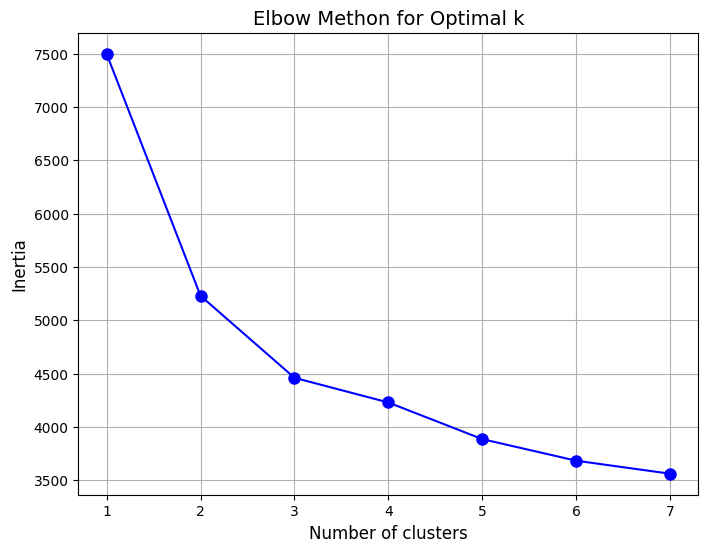

In [63]:
k_range = range(1, 8)
inertia = [KMeans(n_clusters=k, random_state=42).fit(mcdonalds).inertia_ for k in k_range]

plt.figure(figsize=(8, 6))
plt.plot(k_range, inertia, 'bo-', markersize=8)
plt.xlabel('Number of clusters', fontsize=12)
plt.ylabel('Inertia', fontsize=12)
plt.title('Elbow Methon for Optimal k', fontsize=14)
plt.grid(True)
plt.show()

`4` - хороший вариант, но как по мне, лучше `3`. Но надо разделить на 4 кластера

In [64]:
kmeans = KMeans(n_clusters=4, random_state=42, init=init, n_init=1)
clusters = kmeans.fit_predict(mcdonalds)
pred = pd.DataFrame({'id': id, 'cluster': clusters})

ex_map = pred.merge(exemplar, on='id', how='inner')
mapping = ex_map.set_index('cluster')['Segment'].to_dict()
pred['Segment'] = pred['cluster'].map(mapping)
result = pred[['id', 'Segment']]

mcdonalds['Segment'] = clusters

Изобразим проекцию на плоскость

d:\Documents\Clouds\Google.Drive (kolcharma@gmail.com)\MachineLearning\Курс-симулятор\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


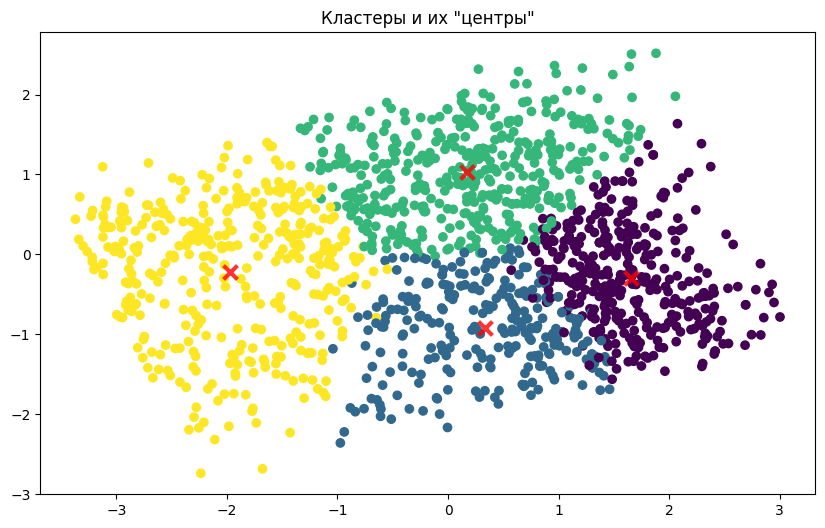

In [65]:
pca = PCA(n_components=2)
data = pca.fit_transform(mcdonalds.drop('Segment', axis=1)) 
cluster_centers_pca = pca.transform(kmeans.cluster_centers_) 
plt.figure(figsize=(10, 6))
plt.scatter(data[:, 0], data[:, 1], c=clusters, cmap='viridis')
plt.scatter(cluster_centers_pca[:, 0], cluster_centers_pca[:, 1], 
            marker='x', color='red', s=100, linewidths=3, alpha=0.8)
plt.title('Кластеры и их "центры"')
plt.show()

In [70]:
mcdonalds['id'] = result['id']

In [71]:
mcdonalds.where(mcdonalds['id'].isin([628, 681, 907, 1061])).dropna()

,yummy,convenient,spicy,fattening,greasy,fast,cheap,tasty,expensive,healthy,disgusting,Like,Age,VisitFrequency,Gender,Segment,id
628,1.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.713463,-0.464605,-1.250756,0.0,0.0,628.0
681,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.392515,-1.027340,0.296582,0.0,1.0,681.0
907,1.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.392515,1.153258,0.296582,0.0,2.0,907.0
1061,0.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,-1.533173,0.309156,1.070251,0.0,3.0,1061.0


In [66]:
result.to_csv('result.csv', index=False)

Итоговый Accuracy: 0.8017894012388163